In [37]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from statsmodels.graphics.tsaplots import plot_predict

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

In [3]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
TICKER = "SPY"

# re-levantamos los splits procesados
data = {
    split:pd.read_csv(PROCESSED_DIR / f"{TICKER.lower()}_{split}.csv", index_col="Date", parse_dates=["Date"])
    for split in ("train","validation","test")
}

# corroboramos datos del EDA
split_summary = pd.DataFrame(
    [{
        "subset": split,
        "filas": len(split_df),
        "fecha_inicio": split_df.index.min(),
        "fecha_fin": split_df.index.max(),
    }
    for split, split_df in data.items()
    ]
).set_index("subset")

display(split_summary)

,filas,fecha_inicio,fecha_fin
subset,,,
train,2706,2010-04-06,2020-12-31
validation,753,2021-01-04,2023-12-29
test,501,2024-01-02,2025-12-30


In [18]:
np.corrcoef(data["train"]["volatility_21d"].values[:-21], data["train"]["volatility_21d"].shift(-21).values[:-21])

array([[1.        , 0.50102427],
       [0.50102427, 1.        ]])

Vamos a definir el target como `volatility_21d`, es decir vamos a intentar predecir la volatilidad medida sobre una ventana de 21 días hábiles.

Como es una ventana de 21 días, si el target se toma a día siguiente resulta muy correlacionada (desvío estándar sobre 21 términos de los cuales 20 son iguales).
Por esto se utiliza la ventana _entera_ siguiente. Es decir, se considera el target como el valor en $t+21$.

In [20]:
# correlacion con día siguiente
shift_days = -1


print(f"Shift de {abs(shift_days)} días")
for split, df in data.items():
    s = df.volatility_21d
    value = s.corr(s.shift(shift_days))
    print(f"{split: >10}: {value.round(3)}")

Shift de 1 días
     train: 0.993
validation: 0.99
      test: 0.986


In [21]:
shift_days = -21


print(f"Shift de {abs(shift_days)} días")
for split, df in data.items():
    s = df.volatility_21d
    value = s.corr(s.shift(shift_days))
    print(f"{split: >10}: {value.round(3)}")

Shift de 21 días
     train: 0.501
validation: 0.684
      test: 0.287


In [24]:
for split, df in data.items():
    df["target"] = df.volatility_21d.shift(-21)
    # hay que eliminar las últimas 21 filas
    df.dropna(inplace=True)

In [25]:
data["train"]

,Adj_Close,Close,High,Low,Open,Volume,price_base,return_simple,return_log,return_abs,volatility_5d,mean_abs_return_5d,volatility_21d,mean_abs_return_21d,volatility_63d,mean_abs_return_63d,return_log_lag_1,return_log_lag_2,return_log_lag_5,return_log_lag_10,year,month,weekday,target
Date,,,,,,,,,,,,,,,,,,,,,,,,
2010-04-06,89.435516,119.040001,119.250000,118.290001,118.419998,110384200,89.435516,0.002358,0.002355,0.002355,0.004680,0.004276,0.004129,0.003684,0.008771,0.006419,0.008116,0.006814,0.006327,0.005332,2010,4,1,0.011099
2010-04-07,88.924652,118.360001,119.360001,117.809998,118.800003,184576300,88.924652,-0.005712,-0.005728,0.005728,0.006104,0.005285,0.004458,0.003949,0.008807,0.006468,0.002355,0.008116,0.000682,0.007008,2010,4,2,0.013198
2010-04-08,89.232658,118.769997,118.970001,117.599998,117.949997,158704000,89.232658,0.003464,0.003458,0.003458,0.005421,0.005294,0.004471,0.004034,0.008813,0.006511,-0.005728,0.002355,-0.003413,-0.004866,2010,4,3,0.013413
2010-04-09,89.818672,119.550003,119.599998,118.800003,119.019997,133006500,89.818672,0.006567,0.006546,0.006546,0.005375,0.005241,0.004552,0.004134,0.008833,0.006548,0.003458,-0.005728,0.006814,-0.001628,2010,4,4,0.016698
2010-04-12,89.961464,119.739998,120.050003,119.559998,119.699997,110279000,89.961464,0.001590,0.001589,0.001589,0.004533,0.003935,0.004527,0.004011,0.008828,0.006521,0.006546,0.003458,0.008116,-0.000600,2010,4,0,0.016687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-11-24,336.698608,363.220001,363.809998,359.290009,360.209991,62415900,336.698608,0.016114,0.015985,0.015985,0.011095,0.009028,0.013581,0.011281,0.013250,0.010779,0.005976,-0.006871,-0.005393,-0.001468,2020,11,1,0.005404
2020-11-25,336.179535,362.660004,363.160004,361.480011,363.130005,45330900,336.179535,-0.001542,-0.001543,0.001543,0.008595,0.006916,0.013541,0.011190,0.013252,0.010769,0.015985,0.005976,-0.012108,0.007401,2020,11,2,0.005616
2020-11-27,337.115723,363.670013,364.179993,362.579987,363.839996,28514100,337.115723,0.002785,0.002781,0.002781,0.008592,0.006631,0.010365,0.009667,0.013234,0.010711,-0.001543,0.015985,0.004201,-0.009748,2020,11,4,0.005653


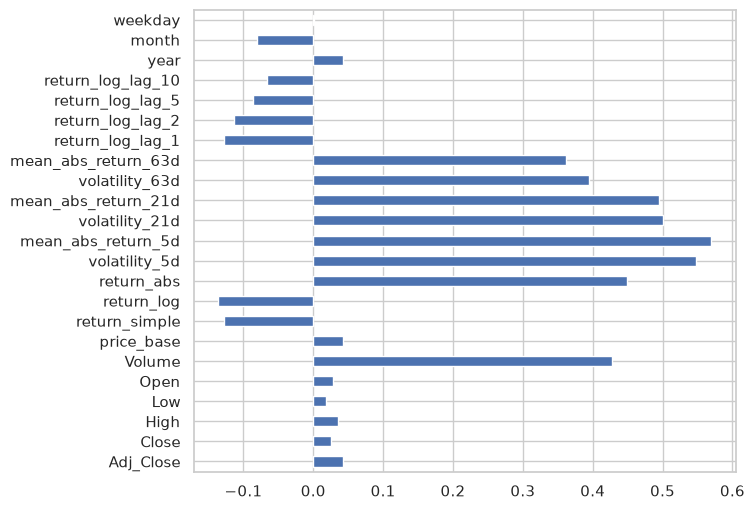

In [38]:
# observamos la correlación de cada variable
(
    data["train"]
    .corr()
    ["target"]
    .drop(index="target")
    .plot(kind="barh", figsize=(7,6))
)
plt.show()

* En general los retornos tienen cierta correlación
* Los valores por ventanas parecen mucho mejores que los simples, exceptuando el retorno absoluto (que es una medida de escala del retorno) y el volumen operado.


In [40]:
def eval_preds(y_true, y_pred):
    eval_fs = {
        "MAE":mean_absolute_error, 
        "RMSE":root_mean_squared_error,
    }

    return {name:f(y_true, y_pred) for name, f in eval_fs.items()}

eval_preds([1,1],[1,2])

{'MAE': 0.5, 'RMSE': 0.7071067811865476}

## Baseline

Se propone como baseline el constante. Dado que no es un modelo entrenable, no tiene sentido medir sobre otro split que test.

In [42]:
test_preds_baseline = data["test"].volatility_21d
test_target = data["test"].target

eval_preds(test_target, test_preds_baseline)

{'MAE': 0.004002049328895032, 'RMSE': 0.006499429317561773}

Es importante tener en cuenta el modelo constante porque es suele ser difícil de superar.

In [54]:
test_metrics_df = pd.DataFrame(eval_preds(test_target, test_preds_baseline), index=["constant"]).T
test_metrics_df

,constant
MAE,0.004002
RMSE,0.006499


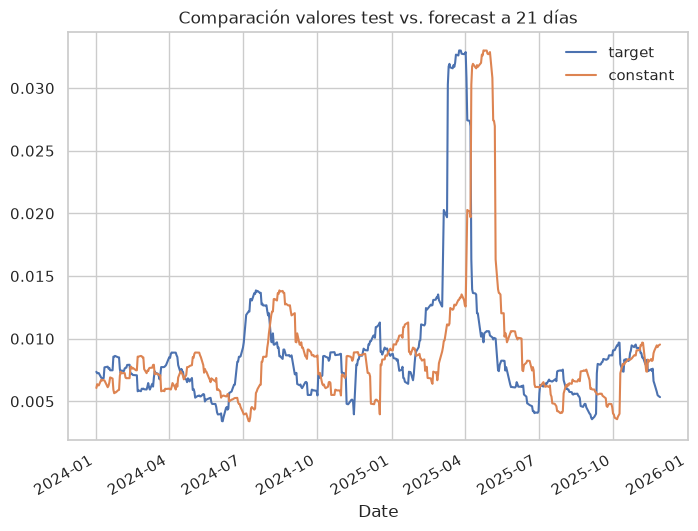

In [56]:
# ploteo pronóstico vs realidad
preds_test_df = data["test"][["target"]].copy()
preds_test_df["constant"] = test_preds_baseline

ax = preds_test_df.plot(figsize=(8,6))
ax.set_title("Comparación valores test vs. forecast a 21 días")
#sns.lineplot(preds_test_df)
plt.show()

## Modelo lineal sobre variables

Como se asume que varias variables no van a ser útiles, pero sí la mayoría, se utiliza _backward elimination_.

Este modelo asume que alguna combinación lineal de las variables generadas en el anterior notebook sirve como predictor para la volatilidad a 21 días.

In [96]:
from collections.abc import Callable

def backward_elimination(
    model_factory: Callable
):
    # data splits son fijos
    X_train = data["train"].drop(columns="target")
    y_train = data["train"].target

    X_val = data["validation"].drop(columns="target")
    y_val = data["validation"].target

    features = list(X_train.columns)

    best_model = model_factory()

    best_model.fit(
        X_train[features],
        y_train,
    )

    best_score = mean_absolute_error(
        y_val,
        best_model.predict(X_val[features]),
    )

    history = [{
        "removed": "",
        "score": best_score,
        "n_features": len(features),
    }]

    while len(features) > 1:
        candidates = []

        for feature_to_remove in features:
            candidate_features = [f for f in features if f != feature_to_remove]

            model = model_factory()

            model.fit(
                X_train[candidate_features],
                y_train,
            )

            score = mean_absolute_error(
                y_val,
                model.predict(X_val[candidate_features]),
            )

            candidates.append(
                {
                    "removed": feature_to_remove,
                    "features": candidate_features,
                    "score": score,
                    "model": model,
                }
            )

        candidates = sorted(
            candidates,
            key=lambda x: x["score"],
        )

        best_candidate = candidates[0]

        if best_candidate["score"] >= best_score:
            break

        print(
            f"Removing {best_candidate['removed']} "
            f"({best_score:.6f} -> {best_candidate['score']:.6f})"
        )

        features = best_candidate["features"]
        best_score = best_candidate["score"]
        best_model = best_candidate["model"]

        history.append(
            {
                "removed": best_candidate["removed"],
                "score": best_candidate["score"],
                "n_features": len(features),
            }
        )

    return {
        "features": features,
        "score": best_score,
        "model": best_model,
        "history": pd.DataFrame(history),
    }

In [97]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


def linear_factory():
    return make_pipeline(StandardScaler(), LinearRegression())

res_linear = backward_elimination(linear_factory)

Removing year (0.009254 -> 0.003846)
Removing Volume (0.003846 -> 0.003166)
Removing High (0.003166 -> 0.003062)
Removing month (0.003062 -> 0.003000)
Removing mean_abs_return_21d (0.003000 -> 0.002988)
Removing return_log_lag_10 (0.002988 -> 0.002987)
Removing return_log (0.002987 -> 0.002987)
Removing Adj_Close (0.002987 -> 0.002987)
Removing price_base (0.002987 -> 0.002527)
Removing return_abs (0.002527 -> 0.002523)
Removing weekday (0.002523 -> 0.002522)


<Axes: title={'center': 'Mejora de MAE en validación por backward elimination'}, xlabel='Variable removida', ylabel='MAE'>

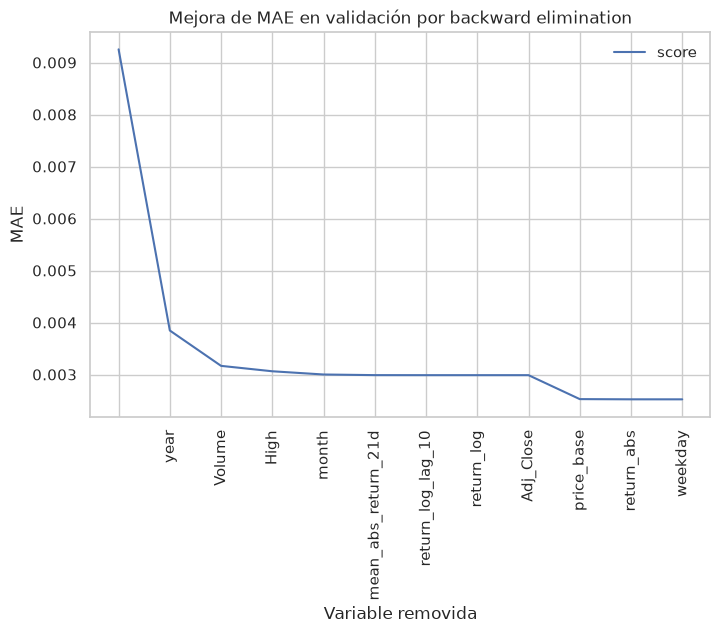

In [98]:
def plot_improvement(res):
    hist = res["history"]
    ax = hist.plot(x="removed",y="score", rot=90, figsize=(8,5))
    ax.set_xticks(range(len(hist)))
    ax.set_xticklabels(
        hist["removed"],
        rotation=90,
    )
    ax.set_ylabel("MAE")
    ax.set_xlabel("Variable removida")
    ax.set_title("Mejora de MAE en validación por backward elimination")
    return ax

plot_improvement(res_linear)

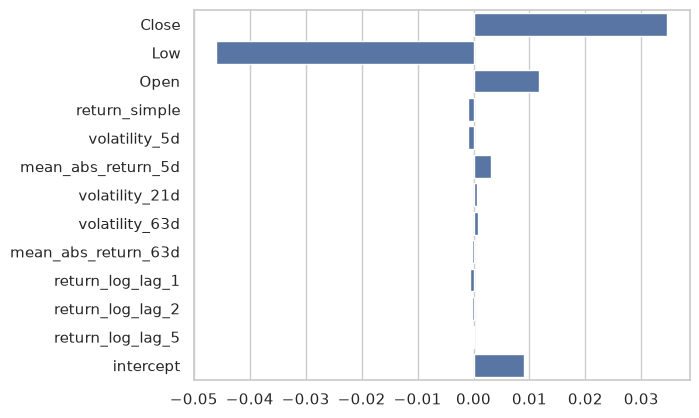

In [99]:
# vemos los coeficientes de cada variable
sns.barplot(x=res_linear["model"][-1].coef_.tolist()+[res_linear["model"][-1].intercept_], y=res_linear["features"]+["intercept"])
plt.show()

In [100]:
test_preds_linear = res_linear["model"].predict(data["test"][res_linear["features"]])

preds_test_df["linear"] = test_preds_linear
test_metrics_df["linear"] = eval_preds(test_target, test_preds_linear)
test_metrics_df

,constant,linear
MAE,0.004002,0.003687
RMSE,0.006499,0.005410


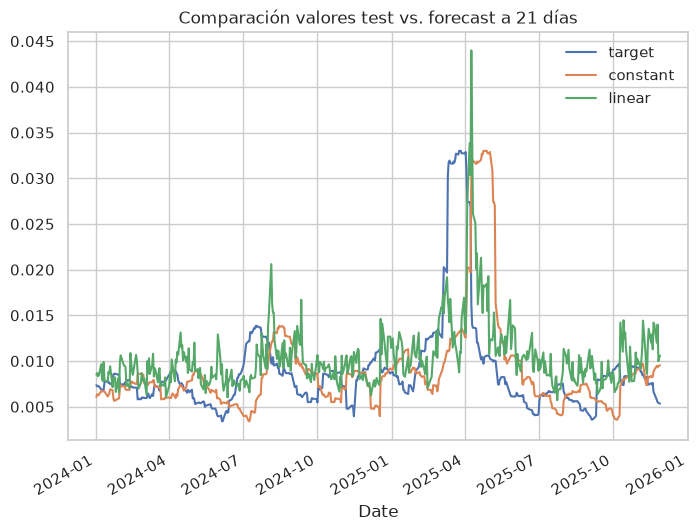

In [ ]:
# ploteo pronóstico vs realidad
ax = preds_test_df.plot(figsize=(8,6))
ax.set_title("Comparación valores test vs. forecast a 21 días")
plt.show()

* Las variables con más peso están relacionadas a los valores de apertura, piso y cierre. Probablemente esto esté relacionado al volumen y a la volatilidad propia por día.
* Del gráfico se puede observar que el modelo es notablemente más ruidoso que la versión constante, que heredaba cierta suavidad de ser rolleada sobre 21 días.

## Random Forests

Los modelos de Random Forest (y en general basados en árboles) tienen la desventaja de necesitar variables que ya tengan capacidad predictiva, no funcionan solo con valores de la serie.
A cambio, son invariantes a transformaciones que preserven orden (lo cual elimina la necesidad de reescalamiento) y manejan relaciones no lineales entre variables de forma natural.

Por último, el forecasting de los modelos basados en árboles es constante, aunque bajo el esquema tomado a 21 días no afecta.

In [102]:
from sklearn.ensemble import RandomForestRegressor

def rf_factory():
    return RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=-1,
    )

res_rf_bw_elim = backward_elimination(rf_factory)

Removing High (0.015152 -> 0.013567)
Removing mean_abs_return_63d (0.013567 -> 0.012823)
Removing volatility_63d (0.012823 -> 0.010691)
Removing month (0.010691 -> 0.004080)
Removing mean_abs_return_21d (0.004080 -> 0.003656)
Removing year (0.003656 -> 0.003393)
Removing Open (0.003393 -> 0.003222)
Removing volatility_21d (0.003222 -> 0.003165)
Removing Volume (0.003165 -> 0.003095)
Removing Low (0.003095 -> 0.003079)
Removing weekday (0.003079 -> 0.003066)
Removing return_log (0.003066 -> 0.003050)


<Axes: title={'center': 'Mejora de MAE en validación por backward elimination'}, xlabel='Variable removida', ylabel='MAE'>

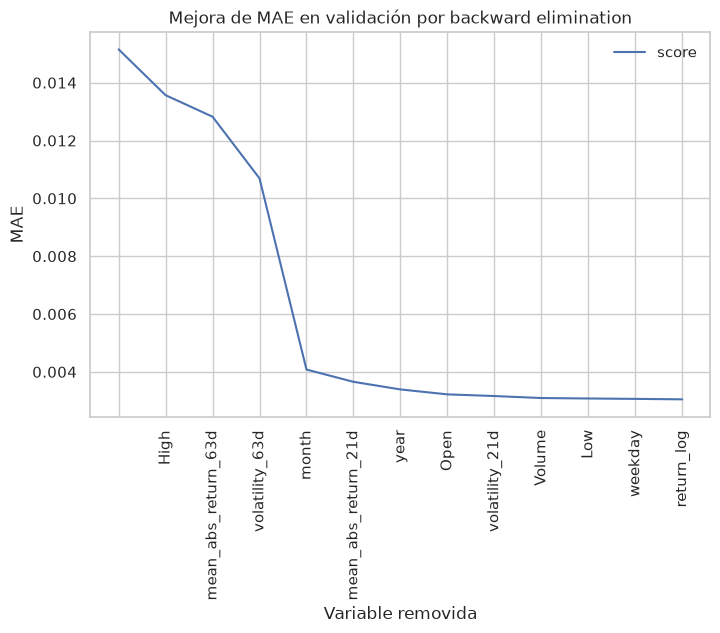

In [103]:
plot_improvement(res_rf_bw_elim)

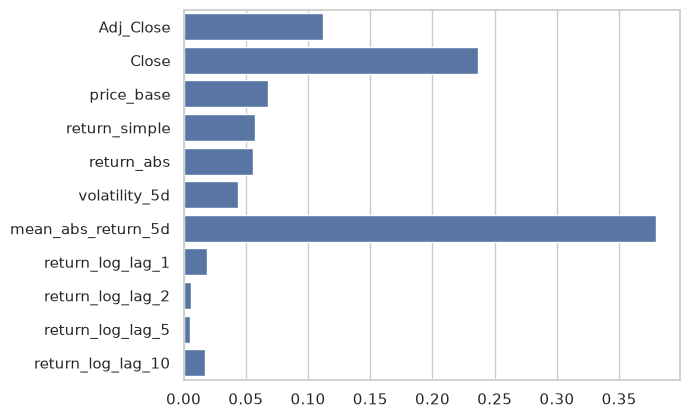

In [105]:
# vemos las importancias de cada variable
sns.barplot(x=res_rf_bw_elim["model"][-1].feature_importances_, y=res_rf_bw_elim["features"])
plt.show()

In [106]:
test_preds_rf = res_rf_bw_elim["model"].predict(data["test"][res_rf_bw_elim["features"]])

preds_test_df["rf"] = test_preds_rf
test_metrics_df["rf"] = eval_preds(test_target, test_preds_rf)
test_metrics_df

,constant,linear,rf
MAE,0.004002,0.003687,0.003273
RMSE,0.006499,0.005410,0.006780


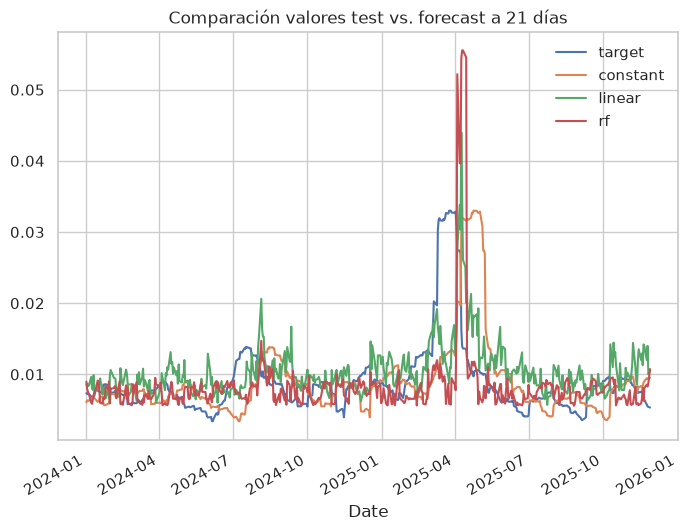

In [107]:
# ploteo pronóstico vs realidad
ax = preds_test_df.plot(figsize=(8,6))
ax.set_title("Comparación valores test vs. forecast a 21 días")
plt.show()

In [112]:
# variables compartidas y de cada uno
vars_linear = set(res_linear["features"])
vars_rf = set(res_rf_bw_elim["features"])

print("Compartidas:", vars_linear & vars_rf)

print("Solo lineal:", vars_linear - vars_rf)
print("Solo RF:",vars_rf - vars_linear)

Compartidas: {'return_log_lag_2', 'volatility_5d', 'mean_abs_return_5d', 'return_log_lag_5', 'return_simple', 'Close', 'return_log_lag_1'}
Solo lineal: {'volatility_63d', 'volatility_21d', 'mean_abs_return_63d', 'Open', 'Low'}
Solo RF: {'Adj_Close', 'return_abs', 'return_log_lag_10', 'price_base'}


* El modelo Random Forest es incluso más variable que el lineal.
* Mejora el MAE incluso más que el modelo lineal, pero el RMSE es peor que el constante. Esto se condice con la observación de mayor variabilidad: los peores errores son peores que para los otros modelos.
* Algunas variables como los log returns con primeros lags son compartidos, pero hay otras variables en donde difieren. Por ejemplo, el modelo lineal usa los valores de apertura y mínimo, mientras que RF los ignora.

## RNN

Dada la mejora parcial del Random Forest por sobre el modelo lineal basado en predictores, se propone una red neuronal como siguiente nivel de complejización. En este punto el interrogante es si las mejoras en MAE compensarán las pérdidas en RMSE.

In [135]:
# variables de escala razonable, sin lags
features_net = [
    "return_log",
    "return_abs",
    "volatility_5d",
    "volatility_21d",
    "volatility_63d",
]

In [136]:
def make_sequences(X, y, lookback=21):
    X_seq = []
    y_seq = []

    for i in range(lookback - 1, len(X)):
        X_seq.append(
            X[i - lookback + 1 : i + 1]
        )
        y_seq.append(
            y.iloc[i]
        )

    return (
        np.array(X_seq),
        np.array(y_seq),
    )

In [137]:
ss = StandardScaler()
X_train = ss.fit_transform(data["train"].drop(columns="target")[features_net])
y_train = data["train"].target

X_val = ss.transform(data["validation"].drop(columns="target")[features_net])
y_val = data["validation"].target

X_test_rnn = ss.transform(data["test"].drop(columns="target")[features_net])
y_test_rnn = data["test"].target

In [138]:
LOOKBACK=21

X_train_seq, y_train_seq = make_sequences(X_train, y_train, LOOKBACK)
X_val_seq, y_val_seq = make_sequences(X_val, y_val, LOOKBACK)
X_test_seq, y_test_seq = make_sequences(X_test_rnn, y_test_rnn, LOOKBACK)

In [139]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

model = Sequential([
    LSTM(32),
    Dense(1),
])

model.compile(
    optimizer="adam",
    loss="mae",
)

model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=32,
)

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0229 - val_loss: 0.0098
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0105 - val_loss: 0.0067
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0078 - val_loss: 0.0060
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0066 - val_loss: 0.0068
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0056 - val_loss: 0.0054
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0056 - val_loss: 0.0041
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0051 - val_loss: 0.0040
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0044 - val_loss: 0.0045
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0046 - val_loss: 0.0050
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0051 - val_loss: 0.0037
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0047 - val_loss: 0.0034
Epoch 12/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0

In [145]:
preds_test_df

,target,constant,linear,rf
Date,,,,
2024-01-02,0.007359,0.006066,0.008521,0.008983
2024-01-03,0.007238,0.006369,0.008683,0.007925
2024-01-04,0.007255,0.006281,0.008340,0.007533
2024-01-05,0.007251,0.006272,0.008406,0.007293
2024-01-08,0.006885,0.006731,0.009646,0.006029
...,...,...,...,...
2025-11-21,0.006417,0.009041,0.013973,0.008087
2025-11-24,0.005766,0.009465,0.011996,0.008555
2025-11-25,0.005498,0.009324,0.013997,0.008293


In [148]:
test_preds_rnn = model.predict(X_test_seq).flatten()

#preds_test_df["rnn"] = test_preds_rnn

preds_test_df.loc[
    preds_test_df.index[LOOKBACK - 1:],
    "rnn"
] = test_preds_rnn

test_metrics_df["rnn"] = eval_preds(y_test_seq, test_preds_rnn)
test_metrics_df

 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


,constant,linear,rf,rnn
MAE,0.004002,0.003687,0.003273,0.004138
RMSE,0.006499,0.005410,0.006780,0.008934


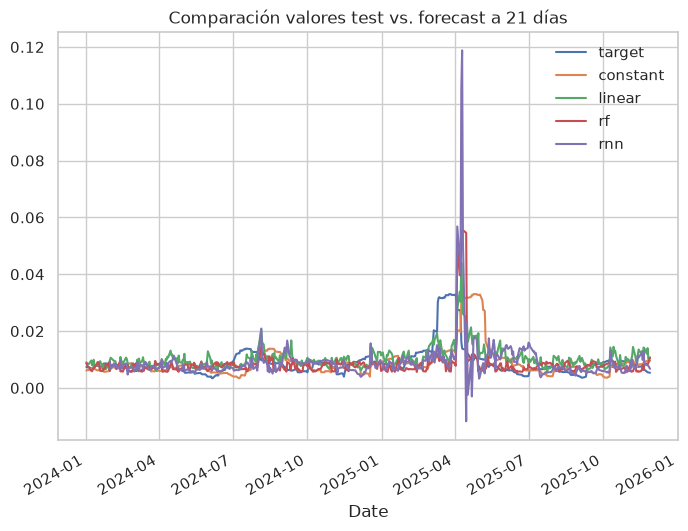

In [149]:
# ploteo pronóstico vs realidad
ax = preds_test_df.plot(figsize=(8,6))
ax.set_title("Comparación valores test vs. forecast a 21 días")
plt.show()

* El desempeño de las RNN es notoriamente peor, incluso para un modelo muy simple: tiene demasiada variabilidad y no la compensa con mejor poder predictivo en las regiones "no anómalas".
* Es peor que el modelo constante.
* Fue la única que llegó a predecir valores negativos.
* Dado el nivel de variabilidad en las predicciones y la simplicidad de la red, es claro que agregar más capas resultaría en un resultado aún peor.

## Conclusiones

En este notebook se evaluaron modelos constante, lineal, random forest y LSTM para predecir la volatilidad a 21 días en base a diferentes variables producto del feature engineering previo.

Se observó que el modelo constante es muy competitivo, lo cual se condice con la literatura y los comentarios teóricos cubiertos en clase respecto de la dificultad para predecir mercados.

Los modelos lineal y random forest resultaron mejores que el baseline, aunque la diferencia en MAE no fue sustancial. El RMSE, en el caso del modelo RF, fue peor que el baseline.

Se confirmó la dificultad para la predicción de series relacionadas a mercados, incluso si la magnitud de interés es la volatilidad, la cual presenta períodos de calma y otros con valores muy altos.